In [1]:
from mysqldatabase import *
import numpy as np
import pandas as pd
from sklearn.impute import KNNImputer
import re

In [2]:
dbo = Database()
laptops = dbo.import_table('laptops_uncleaned')
dbo.close()

In [3]:
np.round(laptops.describe(),2)

,spec_score,user_rating
count,7107.00,7184.00
mean,56.97,4.32
std,12.33,0.33
min,7.00,0.50
25%,50.00,4.15
50%,56.00,4.35
75%,65.00,4.55
max,98.00,5.00


In [4]:
laptops.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7297 entries, 0 to 7296
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   name         7297 non-null   object 
 1   price        7297 non-null   object 
 2   spec_score   7107 non-null   float64
 3   user_rating  7184 non-null   float64
 4   cpu1         7116 non-null   object 
 5   cpu2         6636 non-null   object 
 6   ram          7108 non-null   object 
 7   hdd          1600 non-null   object 
 8   ssd          5921 non-null   object 
 9   gpu          6688 non-null   object 
 10  display      7105 non-null   object 
 11  os           7035 non-null   object 
 12  warranty     6304 non-null   object 
 13  img          7297 non-null   object 
dtypes: float64(2), object(12)
memory usage: 798.2+ KB


In [5]:
laptops.duplicated().sum()

161

In [6]:
laptops.duplicated(subset=('name')).sum()

189

In [7]:
laptops.duplicated(subset=('name','price')).sum()

162

## 🔍 Data Quality Assessment

### 🧼 Dirty Data Issues

#### 📌 Completeness
- **Missing values** detected in the following columns:
  - `spec_score`
  - `user_rating`
  - `cpu1`
  - `cpu2`
  - `ram`
  - `hdd`
  - `ssd`
  - `gpu`
  - `display`
  - `os` *(consider imputing using brand name)*
  - `warranty`

- **Unnecessary rows**:
  - Drop duplicate devices
  - Drop `null` rows

---

#### 📌 Validity
- **Incorrect data types** in:
  - `price`
  - `spec_score`
  - All newly created columns (post feature extraction)

---

#### 📌 Accuracy
- 

---

#### 📌 Consistency
- Inconsistent values found in:
  - `os`
  - All newly created columns

---

### 🧹 Messy Data Issues

- The following columns require cleaning, parsing, or restructuring for better analysis:
  - `name`
  - `cpu1`
  - `cpu2`
  - `ram`
  - `hdd`
  - `ssd`
  - `gpu`
  - `display`

- **Drop column**:
  - `warranty` — not useful for analysis.

- **Column reordering**:
  - Rearrange columns for logical flow and readability.

---

### 📊 Price Column Cleanup

- **Change data type** of `price` to numeric.
- **Outlier detection**:
  - Use `df["price"].describe()` for statistical summary.
  - Visualize with boxplots and/or KDE plots.



In [8]:
# investigating the duplicated rows issue.

name_price_mask = laptops.duplicated(subset=("name", "price"))
name_mask = laptops.duplicated(subset=("name"))

In [9]:
diff_df = laptops[name_mask].merge(
    laptops[name_price_mask],
    how="outer",
    indicator=True
)

result = diff_df[diff_df["_merge"] == "left_only"].drop(columns="_merge")

In [10]:
result

,name,price,spec_score,user_rating,cpu1,cpu2,ram,hdd,ssd,gpu,display,os,warranty,img
13,Dell 14 Latitude 3440 Laptop (12th Gen Core i5...,57100,51.0,4.45,12th Gen Intel Core i5 1235U,"10 Cores (2P + 8E), 12 Threads",16 GB DDR4 RAM,NaN,512 GB SSD,Intel Graphics,"14 inches, 1366 x 768 pixels",Windows 11 OS,1 Year Warranty,https://cdn1.smartprix.com/rx-i119wsrFl-w280-h...
25,Dell Inspiron 3530 OIN353034011RINB1M Laptop (...,48690,47.0,4.50,13th Gen Intel Core i5 1334U,"10 Cores (2P + 8E), 12 Threads",8 GB DDR4 RAM,NaN,512 GB SSD,Intel Integrated Integrated,"15.6 inches, 1920 x 1080 pixels",Windows 11 OS,1 Year Warranty,https://cdn1.smartprix.com/rx-iIhe53CkR-w280-h...
28,Dell Inspiron 5430 IN5430FR0KC001ORS1 Laptop (...,55500,50.0,4.20,13th Gen Intel Core i5 1335U,"10 Cores (2P + 8E), 12 Threads",8 GB LPDDR5 RAM,NaN,512 GB SSD,Intel Iris Xe Graphics,"14 inches, 1920 x 1080 pixels",Windows 11 OS,1 Year Warranty,https://cdn1.smartprix.com/rx-ihacaqXRC-w280-h...
33,Dell Inspiron 5430 IN5430YXVW9M01ORS1 Laptop (...,56350,53.0,4.55,13th Gen Intel Core i5 1335U,"10 Cores (2P + 8E), 12 Threads",8 GB LPDDR5 RAM,NaN,512 GB SSD,Intel Iris Xe Graphics,"14 inches, 1920 x 1080 pixels",Windows 11 OS,1 Year Warranty,https://cdn1.smartprix.com/rx-i60sAZJNM-w280-h...
34,Dell Inspiron 3520 D560866WIN9S Laptop (12th G...,47100,55.0,4.10,12th Gen Intel Core i5 1235U,"10 Cores (2P + 8E), 12 Threads",8 GB DDR4 RAM,NaN,512 GB SSD,Intel Iris Xe Graphics,"15.6 inches, 1920 x 1080 pixels",Windows 11 OS,1 Year Warranty,https://cdn1.smartprix.com/rx-i1ZI1wtLa-w280-h...
37,Dell Vostro 3420 Laptop (11th Gen Core i5/ 8GB...,48399,52.0,4.55,11th Gen Intel Core i5 1135G7,"Quad Core, 8 Threads",8 GB DDR4 RAM,NaN,512 GB SSD,Intel UHD Graphics,"14 inches, 1080 x 1920 pixels",Windows 11 OS,1 Year Warranty,https://cdn1.smartprix.com/rx-iUtP9cWiP-w280-h...
48,Dell Inspiron 3501 Laptop (11th Gen Core i3/ 8...,34999,37.0,4.65,11th Gen Intel Core i3,NaN,8 GB DDR4 RAM,1 TB Hard Disk,NaN,Intel Integrated,"15.6 inches, 1920 x 1080 pixels",Windows 10 OS,1 Year Warranty,https://cdn1.smartprix.com/rx-i6oWwXTpt-w280-h...
49,Dell Latitude 3420 GD723ZG84 Laptop (11th Gen ...,49990,44.0,4.35,11th Gen Intel Core i5,NaN,16 GB DDR4 RAM,NaN,512 GB SSD,Intel Integrated Graphics,"14 inches, 1920 x 1080 pixels",Ubuntu OS,3 Year Warranty,https://cdn1.smartprix.com/rx-iOodLgAHe-w280-h...
55,Dell G15-5511 Gaming Laptop (11th Gen Core i7/...,100000,68.0,4.60,11th Gen Intel Core i7 11800H,"Octa Core, 16 Threads",16 GB DDR4 RAM,NaN,512 GB SSD,4 GB NVIDIA GeForce RTX 3050Ti,"15.6 inches, 1920 x 1080 pixels",Windows 11 OS,1 Year Warranty,https://cdn1.smartprix.com/rx-iqkZBtPhU-w280-h...
56,Dell Inspiron 3511 Laptop (10th Gen Core i3/ 8...,35227,55.0,4.20,10th Gen Intel Core i3 1005G1,"Dual Core, 4 Threads",8 GB DDR4 RAM,1 TB Hard Disk,256 GB SSD,Intel Integrated UHD,"15.6 inches, 1920 x 1080 pixels",Windows 10 OS,NaN,https://cdn1.smartprix.com/rx-iX6CVTPl7-w280-h...


In [11]:
laptops['price'] = laptops['price'].astype(np.int32)

In [12]:
laptops[laptops['name'] == 'Dell XPS 13 7390 Laptop (10th Gen Core i5/ 8GB/ 512GB SSD/ Win10)']

,name,price,spec_score,user_rating,cpu1,cpu2,ram,hdd,ssd,gpu,display,os,warranty,img
4029,Dell XPS 13 7390 Laptop (10th Gen Core i5/ 8GB...,92999,51.0,4.25,10th Gen Intel Core i5 1035G1,"Quad Core, 8 Threads",8 GB LPDDR3 RAM,NaN,512 GB SSD,Intel UHD Graphics,"13.3 inches, 3840 x 2160 pixels",Windows 10 OS,1 Year Warranty,https://cdn1.smartprix.com/rx-iedDlBslW-w280-h...
4038,Dell XPS 13 7390 Laptop (10th Gen Core i5/ 8GB...,98699,48.0,4.35,10th Gen Intel Core i5 10210U,"Quad Core, 8 Threads",8 GB LPDDR3 RAM,NaN,512 GB SSD,Intel UHD Graphics,"13.3 inches, 1920 x 1080 pixels",Windows 10 OS,1 Year Warranty,https://cdn1.smartprix.com/rx-iq1nsK1fr-w280-h...


In [13]:
laptops[laptops['name'] == 'Dell XPS 13 7390 Laptop (10th Gen Core i5/ 8GB/ 512GB SSD/ Win10)'].iloc[:,1].mean()

95849.0

In [14]:
update_price = result['name'].values

In [15]:
for name in update_price:
    avg = laptops[laptops['name'] == name].iloc[:,1].mean()
    idx = laptops[laptops['name'] == name].index[0]
    laptops.loc[idx, 'price'] = avg

C:\Users\ST\AppData\Local\Temp\ipykernel_13496\1262400772.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '53174.5' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  laptops.loc[idx, 'price'] = avg


In [16]:
laptops.drop_duplicates(subset=('name'), inplace=True)

In [17]:
laptops.drop(['warranty'], axis=1, inplace=True)

In [18]:
laptops.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7108 entries, 0 to 7296
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   name         7108 non-null   object 
 1   price        7108 non-null   float64
 2   spec_score   6927 non-null   float64
 3   user_rating  7000 non-null   float64
 4   cpu1         6936 non-null   object 
 5   cpu2         6480 non-null   object 
 6   ram          6928 non-null   object 
 7   hdd          1568 non-null   object 
 8   ssd          5771 non-null   object 
 9   gpu          6520 non-null   object 
 10  display      6925 non-null   object 
 11  os           6857 non-null   object 
 12  img          7108 non-null   object 
dtypes: float64(3), object(10)
memory usage: 777.4+ KB


In [19]:
laptops.columns

Index(['name', 'price', 'spec_score', 'user_rating', 'cpu1', 'cpu2', 'ram',
       'hdd', 'ssd', 'gpu', 'display', 'os', 'img'],
      dtype='object')

In [20]:
laptops.dropna(subset=['cpu1', 'cpu2', 'ram','hdd', 'ssd', 'gpu', 'display', 'os'], how='all',inplace=True)

In [21]:
laptops.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6938 entries, 0 to 7296
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   name         6938 non-null   object 
 1   price        6938 non-null   float64
 2   spec_score   6927 non-null   float64
 3   user_rating  6830 non-null   float64
 4   cpu1         6936 non-null   object 
 5   cpu2         6480 non-null   object 
 6   ram          6928 non-null   object 
 7   hdd          1568 non-null   object 
 8   ssd          5771 non-null   object 
 9   gpu          6520 non-null   object 
 10  display      6925 non-null   object 
 11  os           6857 non-null   object 
 12  img          6938 non-null   object 
dtypes: float64(3), object(10)
memory usage: 758.8+ KB


In [22]:
laptops[laptops['name'] == 'Dell Inspiron 17 7779 Laptop (7th Gen Ci7/ 16GB/ 1TB/ Win10)']

,name,price,spec_score,user_rating,cpu1,cpu2,ram,hdd,ssd,gpu,display,os,img
3438,Dell Inspiron 17 7779 Laptop (7th Gen Ci7/ 16G...,109999.0,44.0,4.0,NaN,NaN,16 GB DDR RAM,1 TB Hard Disk,NaN,NVIDIA Geforce GTX NVIDIA GeForce GTX 940MX,"17.3 inches, 1920 x 1080 pixels, Touch Screen",Windows 10 OS,https://cdn1.smartprix.com/rx-iaSmvGJiD-w280-h...


In [23]:
laptops[laptops['os'].isna()]

,name,price,spec_score,user_rating,cpu1,cpu2,ram,hdd,ssd,gpu,display,os,img
663,HP Notebook 14-dk0093au (7QZ52PA) Laptop (Ryze...,42999.0,NaN,4.45,2.1GHz AMD Ryzen 5 3500U processor,NaN,8GB DDR4 RAM,NaN,1TB 5400rpm hard drive + 256GB SSD,"14-inch screen, Radeon Vega 8 Graphics",NaN,NaN,https://cdn1.smartprix.com/rx-iQF5UBoHN-w280-h...
725,HP ProBook 450 G2 (K1V55PA) Laptop (5th Gen Ci...,47800.0,43.0,3.55,5th Gen Intel Core i5 5200U,"Dual Core, 4 Threads",4 GB DDR3 RAM,500 GB Hard Disk,NaN,NaN,15.6 inches,NaN,https://cdn1.smartprix.com/rx-iT9NHtQfs-w280-h...
734,HP 15-ac101TU (N4G35PA) Laptop (5th Gen Ci3/ 4...,24264.0,41.0,4.70,5th Gen Intel Core i3 5005U,"Dual Core, 4 Threads",4 GB DDR3 RAM,1 TB Hard Disk,NaN,Intel HD Graphics 5500,15.6 inches,NaN,https://cdn1.smartprix.com/rx-ik8u9xP2s-w280-h...
944,HP 430 G8 366B1PA Business Laptop (11th Gen Co...,78999.0,NaN,4.65,Processor: Intel Core i7-1165G7 (up to 4.7 GHz...,NaN,Memory & Storage: 8 GB DDR4-3200 MHz RAM (1 x ...,NaN,Storage: 512 GB SSD PCIe NVMe M.2 SSD,Graphics & Networking: Intel Iris X Graphics,NaN,NaN,https://cdn1.smartprix.com/rx-ix7qkmb3W-w280-h...
1096,Lenovo IdeaPad Slim 5 14AKP10 2025 83HX001NIN ...,86990.0,54.0,4.60,Processor: AMD Ryzen AI 7 350,Speed: 2.0GHz (Base) - 5.0GHz (Max),NaN,NaN,NaN,"NPU: Integrated AMD Ryzen AI, up to 50 TOPS",NaN,NaN,https://cdn1.smartprix.com/rx-iFKaK5HiK-w280-h...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7097,Primebook S Wi-Fi Laptop (MediaTek MT8183/ 4GB...,14490.0,30.0,4.15,MediaTek MT8183,Octa Core,4 GB LPDDR4 RAM,128 GB Hard Disk,NaN,NaN,"11.6 inches, 1366 x 768 pixels",NaN,https://cdn1.smartprix.com/rx-ixYukPzD3-w280-h...
7099,Primebook 4G Android Laptop (MediaTek MT8788/ ...,16490.0,26.0,4.45,MediaTek MTK8788,Octa Core,4 GB LPDDR4 RAM,128 GB Hard Disk,NaN,NaN,"11.6 inches, 1366 x 768 pixels",NaN,https://cdn1.smartprix.com/rx-isjT6jTfx-w280-h...
7170,Jio JioBook NB1112MM BLU 2023 Netbook Laptop (...,12990.0,23.0,4.75,Mediatek MT8788,Octa Core,4 GB ‎LPDDR4 RAM,64 GB Hard Disk,NaN,NaN,"11.6 inches, 1366 x 768 pixels",NaN,https://cdn1.smartprix.com/rx-iH0Oj0ha3-w280-h...
7171,Jio JioBook Cloud Laptop (Octa Core/ 4GB/ 64GB...,14999.0,18.0,4.15,Octa Core,NaN,4 GB ‎LPDDR4 RAM,NaN,NaN,NaN,"11.6 inches, 1366 x 768 pixels",NaN,https://cdn1.smartprix.com/rx-i9bWlT2dl-w280-h...


In [24]:
laptops['brand'] = laptops['name'].str.split().str.get(0)

In [25]:
def impute_os(row):
    if pd.isna(row['os']):
        if row['brand'] == 'Apple':
            return 'MacOS'
        else:
            return 'Windows'
    else:
        return row['os']

In [26]:
laptops['os'] = laptops.apply(impute_os, axis = 1)

<Axes: >

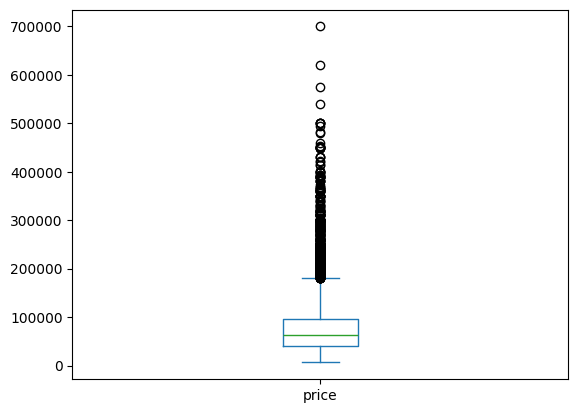

In [27]:
laptops['price'].plot.box()

In [28]:
laptops[laptops['price'] < 15000]

,name,price,spec_score,user_rating,cpu1,cpu2,ram,hdd,ssd,gpu,display,os,img,brand
699,HP 15-bw526au Laptop (AMD E2/ 4GB/ 500GB/ Win10),9994.0,41.0,4.05,AMD APU E2,"Dual Core, 4 Threads",4 GB DDR4 RAM,500 GB Hard Disk,NaN,AMD Radeon,"15.6 inches, 1366 x 768 pixels",Windows 10 OS,https://cdn1.smartprix.com/rx-iHoNkjCP7-w280-h...,HP
723,HP 15-af142AU Notebook (APU AMD A8/ 4GB/ 500GB...,8994.0,30.0,4.10,AMD APU A8,NaN,4 GB RAM,500 GB Hard Disk,NaN,AMD Radeon R5 Series Graphics,"15.6 inches, 1920 x 1080 pixels",Windows 10 OS,https://cdn1.smartprix.com/rx-ivbL0kRxV-w280-h...,HP
1029,Lenovo 100e Chromebook Gen 4 82W00004HA Laptop...,9999.0,27.0,4.15,MediaTek Kompanio 520 520,NaN,4 GB LPDDR4X RAM,NaN,NaN,MediaTek Integrated Arm Mali-G52,"11.6 inches, 1366 x 768 pixels",Chrome OS,https://cdn1.smartprix.com/rx-iaiaW2gSz-w280-h...,Lenovo
1053,Lenovo Ideapad Slim 3 Chrome 14M868 82XJ002RHA...,14990.0,30.0,4.25,MediaTek Kompanio 520 Kompanio 520,Octa Core,8 GB LPDDR4X RAM,NaN,NaN,Arm Mali G52 MC2 2EE Graphics,"14 inches, 1366 x 768 pixels",Chrome OS,https://cdn1.smartprix.com/rx-iZEhFINBC-w280-h...,Lenovo
1059,Lenovo 100e Chromebook Gen 4 82W0001DHAS Lapto...,10999.0,28.0,4.70,MediaTek Kompanio 528 528,NaN,4 GB LPDDR4X RAM,NaN,NaN,MediaTek Integrated Arm Mali-G52,"11.6 inches, 1366 x 768 pixels",Chrome OS,https://cdn1.smartprix.com/rx-iHw3RFa8s-w280-h...,Lenovo
1198,Lenovo Ideapad Slim 3 Chrome 14M868 82XJ002LHA...,13990.0,29.0,4.65,MediaTek Kompanio 520 Kompanio 520,Octa Core,4 GB LPDDR4X RAM,NaN,NaN,Arm Mali G52 MC2 2EE Graphics,"14 inches, 1366 x 768 pixels",Chrome OS,https://cdn1.smartprix.com/rx-iDg9weDfu-w280-h...,Lenovo
1687,Lenovo Miix 320 (80XF00DBIN) Laptop (Atom X5-Z...,6244.0,29.0,4.60,Intel Atom Quad Core X5-Z8350,Quad Core,2 GB DDR3 RAM,NaN,32 GB SSD,Intel HD Graphics,"10.1 inches, 1600 x 900 pixels, Touch Screen",Windows OS,https://cdn1.smartprix.com/rx-ih6l16ICQ-w280-h...,Lenovo
1703,Lenovo Ideapad Flex 10 (59-420157) Netbook (4t...,13990.0,41.0,3.50,4th Gen Intel Celeron Dual Core N2805,Dual Core,2 GB DDR3 RAM,500 GB Hard Disk,NaN,Intel HD Graphics,"10.1 inches, 1366 x 768 pixels, Touch Screen",Windows 8 OS,https://cdn1.smartprix.com/rx-i9s5mMCKw-w280-h...,Lenovo
2192,Asus Chromebook CX1400CKA-EK0257 Laptop (Celer...,13990.0,30.0,4.75,Intel Celeron N4500,"Dual Core, 2 Threads",4 GB LPDDR4X RAM,NaN,64 GB SSD,Intel Integrated UHD,"14 inches, 1920 x 1080 pixels",Chrome OS,https://cdn1.smartprix.com/rx-izNvSKZ8u-w280-h...,Asus
2404,Asus Chromebook CX1500CKA-EJ0277 Laptop (Celer...,13990.0,32.0,4.30,Intel Celeron N4500,"Dual Core, 2 Threads",4 GB LPDDR4X RAM,NaN,128 GB SSD,Intel Integrated UHD,"15.6 inches, 1920 x 1080 pixels",Chrome OS,https://cdn1.smartprix.com/rx-iIvS15Nj5-w280-h...,Asus


In [29]:
laptops.drop([397,2523,3429,4313], axis=0, inplace=True)  # cleaning some old irrelevant laptops

In [30]:
laptops.reset_index(inplace=True)

In [31]:
imputer = KNNImputer(n_neighbors=5)
to_impute = laptops[['price','spec_score','user_rating']]
imputed_df = pd.DataFrame(imputer.fit_transform(to_impute), columns = ['price','spec_score','user_rating'], index = laptops.index)

laptops['spec_score'] = imputed_df['spec_score']
laptops['user_rating'] = imputed_df['user_rating']

In [32]:
laptops.drop(['index'],axis = 1, inplace=True)

In [33]:
laptops.info()   # with this, we ar done handling missing values for now.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6934 entries, 0 to 6933
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   name         6934 non-null   object 
 1   price        6934 non-null   float64
 2   spec_score   6934 non-null   float64
 3   user_rating  6934 non-null   float64
 4   cpu1         6932 non-null   object 
 5   cpu2         6477 non-null   object 
 6   ram          6924 non-null   object 
 7   hdd          1565 non-null   object 
 8   ssd          5768 non-null   object 
 9   gpu          6516 non-null   object 
 10  display      6921 non-null   object 
 11  os           6934 non-null   object 
 12  img          6934 non-null   object 
 13  brand        6934 non-null   object 
dtypes: float64(3), object(11)
memory usage: 758.5+ KB


In [34]:
# Time for feature extraction.

In [35]:
laptops[laptops['cpu1'].str.strip().str.lower().str.replace('\u2009','').str.replace('\u200b','').apply(
    lambda x: (
        'amd' if (('amd' in x) or ('ryzen' in x)) else 'intel' if (('intel' in x) or ('core' in x)) else 'snapdragon' if (('snapdragon' in x) or ('qualcomm' in x)) else 'mediatek' if 'mediatek' in x else 'kirin' if 'kirin' in x else 'microsoft' if 'microsoft' in x else 'apple' if 'apple' in x else 'samsung' if 'exynos' in x else np.nan
    ) if isinstance(x,str) else np.nan
).apply(lambda x: True if pd.isna(x) else False)]

,name,price,spec_score,user_rating,cpu1,cpu2,ram,hdd,ssd,gpu,display,os,img,brand
2958,Asus EeeBook E210MA-GJ011W Laptop (Celeron Dua...,17990.0,37.8,4.75,Stylish & Portable Thin and Light Laptop,11.6 Inch HD,NaN,NaN,NaN,NaN,NaN,Windows,https://cdn1.smartprix.com/rx-iqZvvoW9k-w280-h...,Asus
2988,Asus Zephyrus G14 GA401QC-HZ063TS Gaming Lapto...,116990.0,66.0,4.55,14 inch 14-inch FHD (1920 x 1080) 16:9 anti-gl...,Light Laptop without Optical Disk Drive,NaN,NaN,NaN,NaN,NaN,Pre-installed Genuine Windows 10 OS,https://cdn1.smartprix.com/rx-idZK7FY9E-w280-h...,Asus
3373,Dell Inspiron 17 7779 Laptop (7th Gen Ci7/ 16G...,109999.0,44.0,4.00,NaN,NaN,16 GB DDR RAM,1 TB Hard Disk,NaN,NVIDIA Geforce GTX NVIDIA GeForce GTX 940MX,"17.3 inches, 1920 x 1080 pixels, Touch Screen",Windows 10 OS,https://cdn1.smartprix.com/rx-iaSmvGJiD-w280-h...,Dell
5859,Huawei MateBook Fold Laptop (32GB/ 2TB SSD/ Ha...,319930.0,61.0,4.05,NaN,NaN,32 GB RAM,NaN,2 TB SSD,NaN,"18 inches, 3296 x 2472 pixels, Touch Screen",Windows,https://cdn1.smartprix.com/rx-iH0EKqLhw-w280-h...,Huawei
5988,Samsung Galaxy Book2 15 Laptop (12th Gen Core ...,48990.0,58.6,4.50,This Renewed product is tested to work and loo...,Processor: 12th Generation Intel Core i5-1235U...,NaN,NaN,Storage: 512 GB NVMe SSD,Intel Iris Xe Graphics,NaN,Windows,https://cdn1.smartprix.com/rx-iv4vLOUjP-w280-h...,Samsung


In [36]:
def shift_values(from_column, to_column, value_to_look):
    values_idx = laptops[laptops[from_column].apply(lambda x: True if ((isinstance(x,str)) and (value_to_look.lower() in x.lower())) else False)].index
    laptops.loc[values_idx, to_column] = laptops.loc[values_idx, from_column] 
    laptops.loc[values_idx, from_column] = np.nan

In [37]:
def rename_values(column,to_change,new_value):
    if isinstance(to_change,tuple):
        rename_idx = laptops[laptops[column].isin(to_change)].index
        laptops.loc[rename_idx, column] = new_value
    else:
        rename_idx = laptops[laptops[column] == to_change].index
        laptops.loc[rename_idx, column] = new_value

In [38]:
rename_values('cpu1', ('This Renewed product is tested to work and look like new with minimal to no signs of wea…','Stylish & Portable Thin and Light Laptop'), np.nan)

In [39]:
shift_values('cpu1','display','14 inch 14-inch FHD (1920 x 1080) 16:9 anti-glare display sRGB: 100% Adobe: 75.35% Refre…')

In [40]:
laptops['cpu_brand'] = laptops['cpu1'].str.strip().str.lower().str.replace('\u2009','').str.replace('\u200b','').apply(
    lambda x: (
        'amd' if (('amd' in x) or ('ryzen' in x)) else 'intel' if (('intel' in x) or ('core' in x)) else 'snapdragon' if (('snapdragon' in x) or ('qualcomm' in x)) else 'mediatek' if 'mediatek' in x else 'kirin' if 'kirin' in x else 'microsoft' if 'microsoft' in x else 'apple' if 'apple' in x else 'samsung' if 'exynos' in x else np.nan
    ) if isinstance(x,str) else np.nan
)

In [41]:
laptops['cpu1'] = laptops['cpu1'].str.strip().str.lower().str.replace('\u2009','').str.replace('\u200b','')

In [42]:
laptops['cpu1'].dtype

dtype('O')

In [43]:
for column in laptops.columns:
    if laptops[column].dtype == 'O':
        laptops[column] = laptops[column].str.strip().str.lower().str.replace('\u2009','').str.replace('\u200b','').str.replace('\u200e','').str.replace('\t','')

In [44]:
def get_cpu_name(row):
    if pd.isna(row['cpu_brand']):
        return np.nan
    else:
        if len(row['cpu1'].split(row['cpu_brand'])) > 1:
            return row['cpu1'].split(row['cpu_brand'])[1]
        else:
            return row['cpu1'].split(row['cpu_brand'])[0]
        

In [45]:
laptops['cpu_name'] = laptops.apply(get_cpu_name, axis = 1).str.strip()

In [46]:
laptops['cpu_type'] = laptops['cpu_name'].apply(
    lambda x: (
        re.search(r'\b\d{3,5}[a-zA-Z]{1,2}\b',x).group() if bool(re.search(r'\b\d{3,6}[a-zA-Z]{1,3}\b',x)) else np.nan
    ) if isinstance(x,str) else np.nan
).apply(lambda x: re.findall(r'\d{3,5}([a-zA-Z]{1,2})',x)[0] if isinstance(x,str) else np.nan)

In [47]:
laptops['cpu_name'].str.split('(').str.get(0).str.replace('  ',' ').str.replace('   ',' ').str.replace('processor variant','').str.strip().unique()

array(['ryzen 7 7840hs', 'ryzen 5 7520u', 'core i5 13420h',
       'ryzen 3 7320u', 'core i7 14650hx', 'ryzen 5 5600h',
       'core i3 1315u', 'ryzen 7 5825u', 'ryzen 5 8645hs',
       'core i5 1334u', 'core i7 13620h', 'core i5 12450h',
       'ryzen 7 8845hs', 'core i9 13900hx', 'core ultra 5 series 1 125h',
       'ryzen 9 8945hs', 'ryzen 5 5625u', 'core i3 1215u',
       'core ultra 7 series 1 155h', 'core i7 12650h', 'core i5 1335u',
       'core ultra 5 226v', 'core i7 13700hx', 'core ultra 9 275hx',
       'core i7 1355u', 'athlon 7120u', 'core i5 1235u', 'ryzen 5 8540u',
       'core i3 n305', 'core i5 13500h', 'ryzen 9 7940hs',
       'ryzen 5 7530u', 'core i7 14700hx', 'core i5 11400h',
       'celeron n4020', 'core i5 8265u', 'core ultra 7 155u',
       'core 3 100u', 'ryzen 5 5675u', 'ryzen ai 5 340',
       'core ultra 7 series 2 258v', 'core ultra 7 series 2 256v',
       'ryzen ai 7 350', 'ryzen 7 8840hs', 'ryzen 3 3250u',
       'x plus x1p-42-100', 'ryzen 5 5500u', 'r

In [48]:
laptops[laptops['cpu_name'] == 'mobile workstation']

,name,price,spec_score,user_rating,cpu1,cpu2,ram,hdd,ssd,gpu,display,os,img,brand,cpu_brand,cpu_name,cpu_type
1550,lenovo thinkpad p43s 20rjs06900 laptop (intel ...,219999.0,55.0,4.7,intel mobile workstation,NaN,16gb ddr4 ram,NaN,512gb ssd,2gb nvidia quadro p520,"14inches, 1920x1080pixels",windows 10 os,https://cdn1.smartprix.com/rx-imzy7klrk-w280-h...,lenovo,intel,mobile workstation,NaN


In [49]:
rename_values('cpu_name','n200 n200','pentium n200')
rename_values('cpu_name','n100 n100','pentium n100')
rename_values('cpu_name','kompanio 500 500','kompanio 500')
rename_values('cpu_name','celeron n4020 n4020','celeron n4020')
rename_values('cpu_name','pentium silver n6000','pentium n6000')
rename_values('cpu_name','pentium 4417u 4417u','pentium 4417u')
rename_values('cpu_name','mt8183 mt8183','mt8183')
rename_values('cpu_name','n200','pentium n200')
rename_values('cpu_name','pentium silver  n6000','pentium n6000')
rename_values('cpu_name','7c gen 2 7c gen 2','7c gen 2')
rename_values('cpu_name','ryzen 5 4600h 4600h','ryzen 5 4600h')
rename_values('cpu_name','core i5 core i5','core i5')
rename_values('cpu_name','pentium silver n6000','pentium n6000')
rename_values('cpu_name','pentium 4417u 4417u','pentium 4417u')
rename_values('cpu_name','athlon p3045b 3045b','athlon p3045b')
rename_values('cpu_name','kompanio 520 520','kompanio 520')
rename_values('cpu_name','kompanio 520 kompanio 520','kompanio 520')
rename_values('cpu_name','kompanio 528 528','kompanio 528')
rename_values('cpu_name','ryzen ai 7 ai 7 350','ryzen ai 7 350')
rename_values('cpu_name','',np.nan)
rename_values('cpu_name','x elite x elite','x elite')
rename_values('cpu_name','mobile workstation',np.nan)
rename_values('cpu_name','ryzen 5 hexa core 5600h','ryzen 5 5600h')
rename_values('cpu_name','x x1 x x1 26 100','x x1 26 100')
rename_values('cpu_name','kompanio kompanio 520','kompanio 520')
rename_values('cpu_name','silver n6000 n6000','pentium n6000')
rename_values('cpu_name','pentium dual core 2020m','pentium 2020m')
rename_values('cpu_name','core i7 core i7','core i7')
rename_values('cpu_name','pentium gold 5405u','pentium 5405u')
rename_values('cpu_name','pentium gold 4417u','pentium 4417u')
rename_values('cpu_name','pentium silver n6000 n6000','pentium n6000')
rename_values('cpu_name','celeron n4120 n4120','celeron n4120')
rename_values('cpu_name','qualcomm kryo 495 495','qualcomm kryo 495')
rename_values('cpu_name','athlon 3020e 3020e','athlon 3020e')
rename_values('cpu_name','a4-9120c a4-9120c','a4-9120c')
rename_values('cpu_name','a4-9120 a4-9120','a4-9120')
rename_values('cpu_name','n4100 n4100','n4100')
rename_values('cpu_name','atom x5-z8300 x5-z8300','atom x5-z8300')
rename_values('cpu_name','fx-9830p fx 9830','fx-9830p')
rename_values('cpu_name','7th gen core i5, hm175','7th gen core i5 hm175')
rename_values('cpu_name','7th gen core i7, hm175','7th gen core i7 hm175')
rename_values('cpu_name','m1 max m1 max','m1 max')
rename_values('cpu_name','m1 pro m1 pro','m1 pro')
rename_values('cpu_name','m1 m1','m1')
rename_values('cpu_name','9006c 9006c','9006c')
rename_values('cpu_name','990 990','990')
rename_values('cpu_name','core i7 i7-7500u','core i7-7500u')
rename_values('cpu_name','e2 e2-1800','e2-1800')
rename_values('cpu_name','sq1 sq1','sq1')
rename_values('cpu_name','sq2 sq2','sq2')
rename_values('cpu_name','pentium t6600 t6600','pentium t6600')
rename_values('cpu_name','ryzen 5 2500u 2500u','ryzen 5 2500u')
rename_values('cpu_name','ryzen 3 3250u 3250u','ryzen 3 3250u')
rename_values('cpu_name','ryzen 3 3200u 3200u','ryzen 3 3200u')
rename_values('cpu_name','ryzen 9 ai ai','ryzen 9 ai')
rename_values('cpu_name','core n n100','core n100')
rename_values('cpu_name','pentium n4200 n4200','pentium n4200')
rename_values('cpu_name','celeron n3350 n3350','celeron n3350')
rename_values('cpu_name','® pentium® processor n4200, up to 2.50 ghz','pentium n4200')
rename_values('cpu_name','atom atom','atom')
rename_values('cpu_name','mt8788 mt8788','mt8788')
rename_values('cpu_name','apollo lake n3450 n3450','apollo lake n3450')
rename_values('cpu_name','apollo lake n3450 n3455','apollo lake n3455')

In [50]:
laptops['cpu_name'] = laptops['cpu_name'].str.split('(').str.get(0).str.replace('  ',' ').str.replace('   ',' ').str.replace('processor variant','').str.strip()

In [51]:
laptops['cpu2'].unique()

array(['octa core, 16 threads', 'quad core, 8 threads',
       'octa core (4p + 4e), 12 threads',
       '16 cores (8p + 8e), 24 threads', 'hexa core, 12 threads',
       'hexa core (2p + 4e), 8 threads', '10 cores (2p + 8e), 12 threads',
       '10 cores (6p + 4e), 16 threads',
       '24 cores (8p + 16e), 32 threads',
       '14 cores (4p + 8e + 2lp-e), 18 threads',
       '16 cores (6p + 8e + 2lp-e), 22 threads',
       'octa core (4p + 4lp-e), 8 threads',
       '24 cores (8p + 16e), 24 threads', nan, 'octa core, 8 threads',
       '12 cores (4p + 8e), 16 threads',
       '20 cores (8p + 12e), 28 threads', 'dual core, 2 threads',
       '12 cores (2p + 8e + 2lp-e), 14 threads',
       'octa core (4p + 4e), 8 threads', 'dual core, 4 threads',
       'octa core', 'quad core, 4 threads', '8 threads',
       '14 cores (6p + 8e), 20 threads', '10 cores, 12 threads',
       'dual core', 'quad core', '12 cores', '16 cores, 24 threads',
       'hexa core, 6 threads', '14 cores, 20 threads'

In [52]:
for cpu in laptops['cpu2'].unique():
    if isinstance(cpu,str):
        if 'core' not in cpu:
            print(cpu)

8 threads
speed: 2.0ghz (base) - 5.0ghz (max)
windows 10 home single language 64
20 threads
11.6 inch hd
light laptop without optical disk drive
12 threads
2.9 ghz
linux


In [53]:
laptops[laptops['cpu2'] == 'linux']

,name,price,spec_score,user_rating,cpu1,cpu2,ram,hdd,ssd,gpu,display,os,img,brand,cpu_brand,cpu_name,cpu_type
4934,acer one 14 z422 laptop (amd a6/ 4gb/ 500gb/ f...,21999.0,35.4,4.6,pentium quad core a6,linux,NaN,NaN,NaN,NaN,NaN,windows,https://cdn1.smartprix.com/rx-i13ov9ync-w280-h...,acer,intel,pentium quad core a6,NaN


In [54]:
shift_values('cpu2','display','11.6 inch hd')
shift_values('cpu2','os','linux')

In [55]:
laptops['cpu2'].str.split(',').str.get(0).str.strip().unique()

array(['octa core', 'quad core', 'octa core (4p + 4e)',
       '16 cores (8p + 8e)', 'hexa core', 'hexa core (2p + 4e)',
       '10 cores (2p + 8e)', '10 cores (6p + 4e)', '24 cores (8p + 16e)',
       '14 cores (4p + 8e + 2lp-e)', '16 cores (6p + 8e + 2lp-e)',
       'octa core (4p + 4lp-e)', nan, '12 cores (4p + 8e)',
       '20 cores (8p + 12e)', 'dual core', '12 cores (2p + 8e + 2lp-e)',
       '8 threads', '14 cores (6p + 8e)', '10 cores', '12 cores',
       '16 cores', '14 cores', '5 cores (1p + 4e)',
       'speed: 2.0ghz (base) - 5.0ghz (max)', '10 cores (4p + 6e)',
       'windows 10 home single language 64', '5 cores', '20 threads',
       'light laptop without optical disk drive', '12 threads', '3 cores',
       '2.9 ghz', '14 cores (10p + 4e)', '12 cores (8p + 4e)',
       '12 cores (6p + 6e)', '16 cores (12p + 4e)', '11 cores (5p + 6e)',
       '10 cores (8p + 2e)', 'octa core (6p + 2e)',
       'processor: 12th generation intel core i5-1235u processor (1.3 ghz up to 4.4 g

In [56]:
laptops[laptops['cpu2'] == 'processor: 12th generation intel core i5-1235u processor (1.3 ghz up to 4.4 ghz 12 mb l3…']

,name,price,spec_score,user_rating,cpu1,cpu2,ram,hdd,ssd,gpu,display,os,img,brand,cpu_brand,cpu_name,cpu_type
5988,samsung galaxy book2 15 laptop (12th gen core ...,48990.0,58.6,4.5,NaN,processor: 12th generation intel core i5-1235u...,NaN,NaN,storage: 512 gb nvme ssd,intel iris xe graphics,NaN,windows,https://cdn1.smartprix.com/rx-iv4vloujp-w280-h...,samsung,NaN,NaN,NaN


In [57]:
laptops.loc[5988,'cpu_brand'] = 'intel'
laptops.loc[5988,'cpu_name'] = 'core i5'
laptops.loc[5988,'cpu_type'] = 'u'

In [58]:
rename_values('cpu2',('windows 10 home single language 64','speed: 2.0ghz (base) - 5.0ghz (max)','light laptop without optical disk drive','2.9 ghz','processor: 12th generation intel core i5-1235u processor (1.3 ghz up to 4.4 ghz 12 mb l3…'),np.nan)

In [59]:
def core_mapping(cores):
    if isinstance(cores,str):
        if 'octa' in cores:
            return 8
        elif 'quad' in cores:
            return 4
        elif '16' in cores:
            return 16
        elif 'hexa' in cores:
            return 6
        elif '10' in cores:
            return 10
        elif '24' in cores:
            return 24
        elif '14' in cores:
            return 14
        elif '12' in cores:
            return 12
        elif '20' in cores:
            return 20
        elif 'dual' in cores:
            return 2
        elif '8' in cores:
            return 8
        elif '5' in cores:
            return 5
        elif '3' in cores:
            return 3
        elif '11' in cores:
            return 11
        else:
            np.nan
    else:
        return np.nan

In [60]:
laptops['cpu_cores'] = laptops['cpu2'].str.split(',').str.get(0).str.split('core').str.get(0).str.strip().apply(core_mapping)

In [61]:
laptops['cpu_threads'] = laptops['cpu2'].str.split(',').str.get(1).str.strip().str.split().str.get(0).astype(float)

In [62]:
laptops['ram_capacity'] = laptops['ram'].str.replace('memory & storage: ','').str.split().str.get(0).str.replace('gb','').astype(float)

In [63]:
laptops[laptops['ram_capacity'] == 196]

,name,price,spec_score,user_rating,cpu1,cpu2,ram,hdd,ssd,gpu,display,os,img,brand,cpu_brand,cpu_name,cpu_type,cpu_cores,cpu_threads,ram_capacity


In [64]:
rename_values('ram_capacity',128,196)

In [65]:
laptops['ram_ddr_type'] = laptops['ram'].str.replace('memory & storage: ','').str.replace(' unified memory ram','').str.split().str.get(1).apply(lambda x: re.findall(r'ddr[2-7]', x, flags=re.IGNORECASE)[0] if (isinstance(x,str)) and (re.findall(r'ddr[2-7]', x, flags=re.IGNORECASE)) else np.nan)

In [66]:
laptops.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6934 entries, 0 to 6933
Data columns (total 21 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          6934 non-null   object 
 1   price         6934 non-null   float64
 2   spec_score    6934 non-null   float64
 3   user_rating   6934 non-null   float64
 4   cpu1          6929 non-null   object 
 5   cpu2          6470 non-null   object 
 6   ram           6924 non-null   object 
 7   hdd           1565 non-null   object 
 8   ssd           5768 non-null   object 
 9   gpu           6516 non-null   object 
 10  display       6923 non-null   object 
 11  os            6934 non-null   object 
 12  img           6934 non-null   object 
 13  brand         6934 non-null   object 
 14  cpu_brand     6930 non-null   object 
 15  cpu_name      6926 non-null   object 
 16  cpu_type      5077 non-null   object 
 17  cpu_cores     6470 non-null   float64
 18  cpu_threads   6028 non-null 

In [67]:
laptops['hdd'].str.split('b').str.get(0).str.split('g').str.get(0).str.replace('t','').apply(lambda x: (float(x)*1024 if float(x)<5 else float(x)) if isinstance(x,str) else 0)

0          0.0
1          0.0
2          0.0
3          0.0
4          0.0
         ...  
6929      64.0
6930    1024.0
6931     500.0
6932     500.0
6933    1024.0
Name: hdd, Length: 6934, dtype: float64

In [68]:
laptops[laptops['hdd'] == '1gb hard disk']

,name,price,spec_score,user_rating,cpu1,cpu2,ram,hdd,ssd,gpu,...,os,img,brand,cpu_brand,cpu_name,cpu_type,cpu_cores,cpu_threads,ram_capacity,ram_ddr_type
4598,acer one 14 z2-485 laptop (8th gen ci5/ 4gb/ 1...,51990.0,32.0,4.15,8th gen intel core i5 8250u,"quad core, 8 threads",4gb ddr4 ram,1gb hard disk,NaN,intel uhd graphics 620,...,dos os,https://cdn1.smartprix.com/rx-iihdi60yk-w280-h...,acer,intel,core i5 8250u,u,4.0,8.0,4.0,ddr4
4607,acer one 14 z2-485 laptop (8th gen ci5/ 4gb/ 1...,37990.0,33.0,4.60,8th gen intel core i5 8250u,"quad core, 8 threads",4gb ddr4 ram,1gb hard disk,NaN,intel uhd graphics 620,...,windows home os,https://cdn1.smartprix.com/rx-ix6cyskcq-w280-h...,acer,intel,core i5 8250u,u,4.0,8.0,4.0,ddr4


In [69]:
laptops['hdd'] = laptops['hdd'].str.split('b').str.get(0).str.split('g').str.get(0).str.replace('t','').apply(lambda x: (float(x)*1024 if float(x)<5 else float(x)) if isinstance(x,str) else 0)

In [70]:
laptops['ssd'].value_counts()

ssd
512gb ssd                                                       3343
1tb ssd                                                         1181
256gb ssd                                                        897
128gb ssd                                                        187
2tb ssd                                                          111
32gb ssd                                                          18
64gb ssd                                                           8
4tb ssd                                                            7
8gb ssd                                                            2
240gb ssd                                                          2
24gb ssd                                                           2
6tb ssd                                                            1
480gb ssd                                                          1
62gb ssd                                                           1
storage: 512 gb nvme ssd      

In [71]:
laptops[laptops['ssd'] == '120gb ssd']

,name,price,spec_score,user_rating,cpu1,cpu2,ram,hdd,ssd,gpu,...,os,img,brand,cpu_brand,cpu_name,cpu_type,cpu_cores,cpu_threads,ram_capacity,ram_ddr_type
6920,cenava p14 notebook (celeron n3450/ 6gb/ 120gb...,24669.0,16.0,4.55,intel celeron n3450,quad core,6gb ddr3l ram,0.0,120gb ssd,NaN,...,windows os,https://cdn1.smartprix.com/rx-isqlugrpm-w280-h...,cenava,intel,celeron n3450,NaN,4.0,NaN,6.0,ddr3


In [72]:
laptops.loc[5988,'ssd'] = '512gb'
laptops.loc[3611,'hdd'] = 1024
laptops.loc[3611,'ram_capacity'] = 4
laptops.loc[3611,'ram_ddr_type'] = 'ddr4'
laptops.loc[3611,'ssd'] = '256gb'
laptops.loc[4730,'ssd'] = 0
laptops.loc[4730,'hdd'] = 1024
laptops.loc[935,'ssd'] = '512gb'
laptops.loc[661,'ssd'] = '256gb'
laptops.loc[661,'hdd'] = 1024

In [73]:
laptops['ssd'] = laptops['ssd'].str.split('b').str.get(0).str.split('g').str.get(0).str.replace('t','').apply(lambda x: (float(x)*1024 if float(x)<7 else float(x)) if isinstance(x,str) else 0)

In [74]:
for gpu in laptops['gpu'].unique():

    if isinstance(gpu,str):
        # gpu = gpu.lower()
        if not (('nvidia' in gpu) or ('amd' in gpu) or ('intel' in gpu) or ('apple' in gpu) or ('core' in gpu) or ('radeon' in gpu) or ('iris' in gpu) or ('integrated uhd' in gpu)):
            print(gpu)
        # if 'core' in gpu:
        #     print(gpu)

qualcomm adreno gpu
mediatek integrated arm mali graphics
mediatek integrated
qualcomm adreno 618 gpu
2gb graphics card
mediatek integrated arm mali-g52
arm mali g52 mc2 2ee graphics
integrated qualcomm adreno gpu
1gb ati graphics
4gb graphics card
2gb mx130 graphics
uhd graphics 600
adreno 685 graphics
6gb graphics card
8gb graphics card
hd graphics 5300
adreno 690 gpu
sq1 adreno 685 gpu
qualcomm adreno graphics
integrated hd graphics
integrated graphics


In [75]:
laptops[laptops['gpu'] == '6gb graphics card']

,name,price,spec_score,user_rating,cpu1,cpu2,ram,hdd,ssd,gpu,...,os,img,brand,cpu_brand,cpu_name,cpu_type,cpu_cores,cpu_threads,ram_capacity,ram_ddr_type
4878,acer predator g9-593 (nh.q1ysi.007) notebook (...,114000.0,46.0,4.57,core i5 (7th gen),NaN,16gb ddr4 ram,1024.0,128.0,6gb graphics card,...,windows os,https://cdn1.smartprix.com/rx-ilel2he8g-w280-h...,acer,intel,core i5,NaN,NaN,NaN,16.0,ddr4
4881,acer predator g9-593 (nh.q1ysi.004) notebook (...,159703.0,52.0,4.20,"7th gen core i7, hm175",NaN,16gb ddr4 ram,1024.0,256.0,6gb graphics card,...,windows 10 os,https://cdn1.smartprix.com/rx-ipxt6nfsj-w280-h...,acer,intel,7th gen core i7 hm175,NaN,NaN,NaN,16.0,ddr4
5177,msi gs65 8re-084in gaming laptop (8th gen ci7/...,134999.0,48.0,4.00,8th gen core i7,NaN,16gb ddr4 ram,0.0,512.0,6gb graphics card,...,windows 10 os,https://cdn1.smartprix.com/rx-ifeb9smqk-w280-h...,msi,intel,8th gen core i7,NaN,NaN,NaN,16.0,ddr4
5654,msi gv62vr 7rf-1067in gaming laptop (7th gen c...,108990.0,53.0,4.10,7th gen core i7,NaN,16gb ddr4 ram,1024.0,128.0,6gb graphics card,...,windows 10 os,https://cdn1.smartprix.com/rx-is3rdtowm-w280-h...,msi,intel,7th gen core i7,NaN,NaN,NaN,16.0,ddr4
5659,msi dominator pro gt72 2qd gaming laptop (4th ...,165000.0,51.0,4.18,4th gen core i7 4710hq processor variant,NaN,8gb ddr3 ram,1024.0,0.0,6gb graphics card,...,windows 8 os,https://cdn1.smartprix.com/rx-itawkacpt-w280-h...,msi,intel,4th gen core i7 4710hq,hq,NaN,NaN,8.0,ddr3
5663,msi gv62 8re-038in laptop (8th gen ci5/ 8gb/ 1...,81990.0,47.0,4.39,8th gen core i5,NaN,8gb ddr4 ram,1024.0,128.0,6gb graphics card,...,windows 10 os,https://cdn1.smartprix.com/rx-ijou06yvo-w280-h...,msi,intel,8th gen core i5,NaN,NaN,NaN,8.0,ddr4


In [76]:
laptops.loc[658,'gpu'] = 'amd'

In [77]:
def get_gpu_brand(gpu):
    if isinstance(gpu,str):
        if ('amd' in gpu) or ('radeon' in gpu) or ('ati' in gpu):
            return 'amd'
        if ('nvidia' in gpu) or ('mx' in gpu) or (gpu == '2gb graphics card') or (gpu == '4gb graphics card') or (gpu == '6gb graphics card') or (gpu == '8gb graphics card'):
            return 'nvidia'
        if ('apple' in gpu) or ('core' in gpu):
            return 'apple'
        if ('intel' in gpu) or ('iris' in gpu) or ('integrated uhd' in gpu) or ('uhd graphics' in gpu) or ('integrated hd' in gpu) or ('integrated graphics' in gpu) or ('hd graphics' in gpu):
            return 'intel'
        else:
            return 'other'
    else:
        return np.nan

In [78]:
laptops['gpu_brand'] = laptops['gpu'].apply(get_gpu_brand)

In [79]:
for gpu in laptops[laptops['gpu_brand'] == 'intel']['gpu'].unique():
    if isinstance(gpu,str):
        if 'intel' not in gpu:
            print(gpu)

integrated uhd graphics 620
iris plus graphics
2gb integrated uhd graphics 620
integrated uhd 620
iris xe graphics
integrated iris plus gpu
uhd graphics 600
integrated uhd 605
hd graphics 5300
iris pro graphics
integrated hd graphics
integrated graphics


In [80]:
laptops['gpu_vram'] = laptops['gpu'].apply(lambda x: re.findall(r'\b\d+\s*gb\b',x)[0] if (isinstance(x,str)) and (bool(re.findall(r'\b\d+\s*gb\b',x))) else np.nan).str.replace('gb','').astype(float)

In [81]:
laptops['gpu'].unique()

array(['8gb nvidia geforce rtx 4060', 'amd radeon graphics',
       '6gb nvidia geforce rtx 4050', 'amd radeon amd',
       '4gb amd radeon rx 6500m', 'intel integrated uhd',
       '6gb nvidia geforce rtx 3050', 'intel integrated',
       '4gb nvidia geforce rtx 2050', 'intel uhd graphics',
       'intel iris xe graphics', '4gb amd radeon amd radeon rx 6500m',
       '4gb nvidia geforce rtx 3050', 'intel integrated graphics',
       'intel integrated iris xe', 'intel integrated uhd graphics',
       'intel arc integrated', 'intel arc graphics',
       '16gb nvidia geforce rtx 5080', 'amd integrated',
       '4gb nvidia geforce rtx 3050a', '8gb nvidia geforce rtx 4070',
       'intel iris x graphics', '4gb nvidia geforce gtx 1650',
       'integrated uhd graphics 620', '4gb amd radeon rx 6500m graphics',
       'integrated intel graphics',
       'amd radeon vega 7 integrated graphics',
       'amd radeon 840m graphics', 'amd radeon 860m graphics',
       '4gb nvidia rtx a500', '4gb nv

In [82]:
laptops['gpu_brand'].unique()

array(['nvidia', 'amd', 'intel', 'other', nan, 'apple'], dtype=object)

In [83]:
def get_gpu_name(row):
    gpu = row['gpu']
    brand = row['gpu_brand']
    if isinstance(gpu,str):
        if isinstance(brand,str):
            if 'integrated' in gpu:
                return 'integrated'
            else:
                if brand != 'other':
                    gpu_sp_list = gpu.split(brand)
                    if len(gpu_sp_list) > 1:
                        return gpu.split(brand)[1].replace('graphics','').replace('uhd','')
                    else:
                        return gpu.split(brand)[0].replace('graphics','').replace('uhd','')
                else:
                    return gpu
        else:
            return np.nan
    else:
        return np.nan

In [84]:
integrated_gpus = []
for gpu in laptops.apply(get_gpu_name, axis=1).str.strip().unique():
    if not pd.isna(gpu):
        if ('geforce' not in gpu) and ('rx' not in gpu) and ('integrated' not in gpu) and ('rtx' not in gpu) and ('gtx' not in gpu):
            integrated_gpus.append(gpu)
integrated_gpus = tuple(integrated_gpus)

In [85]:
laptops['gpu_name'] = laptops.apply(get_gpu_name, axis=1).str.strip()

In [86]:
rename_values('gpu_name',integrated_gpus,'integrated')

In [87]:
laptops[laptops['gpu'].apply(lambda x: True if not pd.isna(x) and '14-inch' in x else False)]

,name,price,spec_score,user_rating,cpu1,cpu2,ram,hdd,ssd,gpu,...,cpu_brand,cpu_name,cpu_type,cpu_cores,cpu_threads,ram_capacity,ram_ddr_type,gpu_brand,gpu_vram,gpu_name
661,hp notebook 14-dk0093au (7qz52pa) laptop (ryze...,42999.0,51.4,4.45,2.1ghz amd ryzen 5 3500u processor,NaN,8gb ddr4 ram,1024.0,256.0,"14-inch screen, radeon vega 8 graphics",...,amd,ryzen 5 3500u processor,u,NaN,NaN,8.0,ddr4,amd,NaN,integrated


In [88]:
laptops['screen_size'] = laptops['display'].str.split(',').str.get(0).str.strip()
laptops['screen_res'] = laptops['display'].str.split(',').str.get(1).str.strip()
laptops['touchscreen'] = laptops['display'].str.split(',').str.get(2).str.strip()

In [89]:
laptops.loc[661,'screen_size'] = 14

In [90]:
laptops[laptops['screen_res'] == 'touch screen']

,name,price,spec_score,user_rating,cpu1,cpu2,ram,hdd,ssd,gpu,...,cpu_cores,cpu_threads,ram_capacity,ram_ddr_type,gpu_brand,gpu_vram,gpu_name,screen_size,screen_res,touchscreen
94,hp envy x360 14-fc0124tu laptop (intel core ul...,102499.0,56.0,4.45,intel core ultra 7 155u,"12 cores (2p + 8e + 2lp-e), 14 threads",16gb lpddr5 ram,0.0,512.0,integrated intel graphics,...,12.0,14.0,16.0,ddr5,intel,NaN,integrated,14inches,touch screen,NaN
6776,micromax canvas laptab lt666w (aqc/ 2gb/ 32gb ...,11999.0,33.0,4.15,intel atom quad core z3735f,quad core,2gb ddr3 ram,32.0,0.0,intel hd graphics,...,4.0,NaN,2.0,ddr3,intel,NaN,integrated,10.1inches,touch screen,NaN


In [91]:
shift_values('screen_res','touchscreen','touch screen')
rename_values('screen_res','touch screen',np.nan)

In [92]:
laptops['screen_size'].unique()

array(['16.1inches', '15.6inches', '14inches', '16inches', '17.3inches',
       '13.3inches', '14.1inches', '11.6inches', '13.5inches',
       '13.4inches', '15inches', 14, '12.5inches', '10.1inches', nan,
       '15.3inches', '15.28inches', '14.5inches', '14.22inches',
       '10.95inches', '13inches', '18inches', '17inches', '11.6 inch hd',
       '14 inch 14-inch fhd (1920 x 1080) 16:9 anti-glare display srgb: 100% adobe: 75.35% refre…',
       '16.3inches', '15.56inches', '12.3inches', '13.86inches',
       '14.96inches', '15.8inches', '1366x768pixels', '12inches',
       '15.6 inches (39.62 cm)', '1920x1080pixels', '15.2inches',
       '15.75inches', '17.32inches', '18.4inches', '13.6inches',
       '16.2inches', '14.2inches', '15.4inches', '13.17inches',
       '11inches', '15.25inches', '12.6inches', '13.9inches',
       '13.8inches', '12.4inches', '14.4inches', '10.5inches', '10inches',
       '12.87inches', '17.26inches', '14.6inches', '12.2inches',
       '15.84inches', '7inc

In [93]:
shift_values('screen_size','screen_res','1366x768pixels')
shift_values('screen_size','screen_res','1920x1080pixels')
rename_values('screen_size','1366x768pixels',np.nan)
rename_values('screen_size','1920x1080pixels',np.nan)

In [94]:
laptops['screen_size'] = laptops['screen_size'].str.split('inch').str.get(0).str.strip().astype(float)

In [95]:
laptops['screen_res'] = laptops['screen_res'].str.replace('pixels','').str.replace('pixel','').str.strip()

In [96]:
laptops['screen_size'].unique()

array([16.1 , 15.6 , 14.  , 16.  , 17.3 , 13.3 , 14.1 , 11.6 , 13.5 ,
       13.4 , 15.  ,   nan, 12.5 , 10.1 , 15.3 , 15.28, 14.5 , 14.22,
       10.95, 13.  , 18.  , 17.  , 16.3 , 15.56, 12.3 , 13.86, 14.96,
       15.8 , 12.  , 15.2 , 15.75, 17.32, 18.4 , 13.6 , 16.2 , 14.2 ,
       15.4 , 13.17, 11.  , 15.25, 12.6 , 13.9 , 13.8 , 12.4 , 14.4 ,
       10.5 , 10.  , 12.87, 17.26, 14.6 , 12.2 , 15.84,  7.  , 15.5 ,
       15.35, 13.1 ])

In [97]:
laptops.loc[3619, 'screen_res'] = '1920x1080'

In [98]:
laptops.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6934 entries, 0 to 6933
Data columns (total 27 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          6934 non-null   object 
 1   price         6934 non-null   float64
 2   spec_score    6934 non-null   float64
 3   user_rating   6934 non-null   float64
 4   cpu1          6929 non-null   object 
 5   cpu2          6470 non-null   object 
 6   ram           6924 non-null   object 
 7   hdd           6934 non-null   float64
 8   ssd           6934 non-null   float64
 9   gpu           6516 non-null   object 
 10  display       6923 non-null   object 
 11  os            6934 non-null   object 
 12  img           6934 non-null   object 
 13  brand         6934 non-null   object 
 14  cpu_brand     6930 non-null   object 
 15  cpu_name      6926 non-null   object 
 16  cpu_type      5077 non-null   object 
 17  cpu_cores     6470 non-null   float64
 18  cpu_threads   6028 non-null 

In [99]:
laptops['screen_res'] = laptops['screen_res'].str.replace(" ",'')

In [100]:
laptops['screen_width'] = laptops['screen_res'].str.split('x').str.get(0).astype(float)
laptops['screen_height'] = laptops['screen_res'].str.split('x').str.get(1).astype(float)

In [101]:
def label_laptop_resolution(w, h):
    width, height = sorted([int(w), int(h)])

    if width <= 1024:
        return "SD"
    elif width <= 1280 and height <= 800:
        return "HD"
    elif width <= 1366:
        return "HD+"
    elif width <= 1600 and height <= 900:
        return "HD+"
    elif width <= 1920 and height <= 1080:
        return "FHD"
    elif width <= 1920 and height <= 1200:
        return "WUXGA"
    elif width <= 2560 and height <= 1440:
        return "QHD"
    elif width <= 2560 and height <= 1600:
        return "WQXGA"
    elif width <= 2880 and height <= 1800:
        return "3K"
    elif width <= 3200:
        return "3K+"
    elif width <= 3840 and height <= 2160:
        return "4K UHD"
    else:
        return "Ultra HD+"

In [102]:
laptops['screen_res'] = laptops.apply(lambda x: label_laptop_resolution(x['screen_width'],x['screen_height']) if not ((pd.isna(x['screen_width'])) or (pd.isna(x['screen_height']))) else np.nan, axis = 1)

In [103]:
laptops.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6934 entries, 0 to 6933
Data columns (total 29 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           6934 non-null   object 
 1   price          6934 non-null   float64
 2   spec_score     6934 non-null   float64
 3   user_rating    6934 non-null   float64
 4   cpu1           6929 non-null   object 
 5   cpu2           6470 non-null   object 
 6   ram            6924 non-null   object 
 7   hdd            6934 non-null   float64
 8   ssd            6934 non-null   float64
 9   gpu            6516 non-null   object 
 10  display        6923 non-null   object 
 11  os             6934 non-null   object 
 12  img            6934 non-null   object 
 13  brand          6934 non-null   object 
 14  cpu_brand      6930 non-null   object 
 15  cpu_name       6926 non-null   object 
 16  cpu_type       5077 non-null   object 
 17  cpu_cores      6470 non-null   float64
 18  cpu_thre

In [104]:
laptops['screen_size'].unique()

array([16.1 , 15.6 , 14.  , 16.  , 17.3 , 13.3 , 14.1 , 11.6 , 13.5 ,
       13.4 , 15.  ,   nan, 12.5 , 10.1 , 15.3 , 15.28, 14.5 , 14.22,
       10.95, 13.  , 18.  , 17.  , 16.3 , 15.56, 12.3 , 13.86, 14.96,
       15.8 , 12.  , 15.2 , 15.75, 17.32, 18.4 , 13.6 , 16.2 , 14.2 ,
       15.4 , 13.17, 11.  , 15.25, 12.6 , 13.9 , 13.8 , 12.4 , 14.4 ,
       10.5 , 10.  , 12.87, 17.26, 14.6 , 12.2 , 15.84,  7.  , 15.5 ,
       15.35, 13.1 ])

In [105]:
def aspect_ratio_category(row):

    w = row['screen_width']
    h = row['screen_height']
    aspect_ratio = round(w / h, 2)
    
    if aspect_ratio < 1.5:
        return "Standard (4:3 or 5:4)"
    elif 1.5 <= aspect_ratio < 1.8:
        return "Widescreen (16:10)"
    elif 1.8 <= aspect_ratio < 2.2:
        return "Widescreen (16:9)"
    elif 2.2 <= aspect_ratio < 3:
        return "UltraWide (21:9)"
    else:
        return "Extra UltraWide (32:9 or higher)"

In [106]:
laptops['aspect_ratio_category'] = laptops.apply(lambda x: aspect_ratio_category(x) if not ((pd.isna(x['screen_width'])) or (pd.isna(x['screen_height']))) else np.nan, axis = 1)

In [107]:
laptops['os'] = laptops['os'].apply(
    lambda x: (
        'windows' if (('windows' in x) or ('dos' in x)) else 'macos' if 'mac' in x else 'android' if 'android' in x else 'linux' if 'linux' in x else 'ubuntu' if 'ubuntu' in x else 'chromeos' if 'chrome' in x else x
    ) if not pd.isna(x) else np.nan
)

In [108]:
laptops['ppi'] = round(np.sqrt((laptops['screen_width']*laptops['screen_width']) + (laptops['screen_height']*laptops['screen_height']))/(laptops['screen_size']),2)

In [109]:
laptops.head()

,name,price,spec_score,user_rating,cpu1,cpu2,ram,hdd,ssd,gpu,...,gpu_brand,gpu_vram,gpu_name,screen_size,screen_res,touchscreen,screen_width,screen_height,aspect_ratio_category,ppi
0,hp omen 16-xd0017ax gaming laptop (amd ryzen 7...,118490.0,81.0,4.65,7th gen amd ryzen 7 7840hs,"octa core, 16 threads",32gb ddr5 ram,0.0,1024.0,8gb nvidia geforce rtx 4060,...,nvidia,8.0,geforce rtx 4060,16.1,HD+,NaN,1080.0,1920.0,Standard (4:3 or 5:4),136.83
1,hp 255 g10 laptop (amd ryzen 5 7520u/ 8gb/ 512...,28990.0,50.0,4.40,7th gen amd ryzen 5 7520u,"quad core, 8 threads",8gb ddr4 ram,0.0,512.0,amd radeon graphics,...,amd,NaN,integrated,15.6,SD,NaN,1366.0,768.0,Widescreen (16:10),100.45
2,hp victus 15-fa1319tx gaming laptop (13th gen ...,68841.0,61.0,4.55,13th gen intel core i5 13420h,"octa core (4p + 4e), 12 threads",16gb ddr4 ram,0.0,512.0,6gb nvidia geforce rtx 4050,...,nvidia,6.0,geforce rtx 4050,15.6,HD+,NaN,1920.0,1080.0,Widescreen (16:10),141.21
3,hp 15-fc0154au laptop (amd ryzen 3 7320u/ 8gb/...,30790.0,57.0,4.70,7th gen amd ryzen 3 7320u,"quad core, 8 threads",8gb ddr5 ram,0.0,512.0,amd radeon amd,...,amd,NaN,integrated,15.6,HD+,NaN,1920.0,1080.0,Widescreen (16:10),141.21
4,hp omen 16-wf1096tx gaming laptop (14th gen co...,109100.0,79.0,4.40,14th gen intel core i7 14650hx,"16 cores (8p + 8e), 24 threads",16gb ddr5 ram,0.0,1024.0,8gb nvidia geforce rtx 4060,...,nvidia,8.0,geforce rtx 4060,16.1,HD+,NaN,1920.0,1080.0,Widescreen (16:10),136.83


In [110]:
laptops.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6934 entries, 0 to 6933
Data columns (total 31 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   name                   6934 non-null   object 
 1   price                  6934 non-null   float64
 2   spec_score             6934 non-null   float64
 3   user_rating            6934 non-null   float64
 4   cpu1                   6929 non-null   object 
 5   cpu2                   6470 non-null   object 
 6   ram                    6924 non-null   object 
 7   hdd                    6934 non-null   float64
 8   ssd                    6934 non-null   float64
 9   gpu                    6516 non-null   object 
 10  display                6923 non-null   object 
 11  os                     6934 non-null   object 
 12  img                    6934 non-null   object 
 13  brand                  6934 non-null   object 
 14  cpu_brand              6930 non-null   object 
 15  cpu_

In [111]:
laptops['touchscreen'].value_counts()

touchscreen
touch screen    737
Name: count, dtype: int64

In [112]:
laptops['touchscreen'] = laptops['touchscreen'].apply(lambda x: 1 if not pd.isna(x) else 0)

In [113]:
laptops.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6934 entries, 0 to 6933
Data columns (total 31 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   name                   6934 non-null   object 
 1   price                  6934 non-null   float64
 2   spec_score             6934 non-null   float64
 3   user_rating            6934 non-null   float64
 4   cpu1                   6929 non-null   object 
 5   cpu2                   6470 non-null   object 
 6   ram                    6924 non-null   object 
 7   hdd                    6934 non-null   float64
 8   ssd                    6934 non-null   float64
 9   gpu                    6516 non-null   object 
 10  display                6923 non-null   object 
 11  os                     6934 non-null   object 
 12  img                    6934 non-null   object 
 13  brand                  6934 non-null   object 
 14  cpu_brand              6930 non-null   object 
 15  cpu_

In [114]:
laptops[(laptops['gpu_name'] == 'integrated') & (~laptops['gpu_vram'].isna())]['gpu'].unique()

array(['4gb amd radeon amd radeon rx 6500m', '4gb nvidia quadro t600',
       '4gb  intel arc a370m graphics',
       '4gb intel arc a370m 4gb vram graphics',
       '2gb integrated uhd graphics 620', '2gb amd radeon radeon',
       '2gb amd radeon pro wx 3100',
       '2gb amd radeon amd radeon™ 530 graphics (2 gb ddr3 dedicated)',
       '2gb amd radeon 520',
       '2gb amd radeon amd radeon™ 520 graphics (2 gb ddr3 dedicated)',
       '2gb graphics card', '2gb amd radeon r5 m430',
       '2gb 2 gb amd r7 m360 graphics',
       '2gb amd radeon r5 series m330 graphics', '1gb intel hd graphics',
       '1.5gb 1 gb amd radeon hd 7450m dedicated 512 mb amd radeon hd 6480g graphics integrated',
       '1gb amd radeon hd 8670m', '1gb amd radeon hd 7470m',
       '4gb nvidia quadro t2000 max-q', '4gb nvidia t600',
       '4gb amd radeon 540', '4gb nvidia quadro t1200', '4gb nvidia t550',
       '4gb nvidia quadro t550', '2gb nvidia quadro p520',
       '4gb intel integrated arc a530m', '2g

In [115]:
laptops.apply(lambda row: 0 if (row['gpu_name'] == 'integrated') else row['gpu_vram'], axis=1).value_counts()

0.0     4212
4.0      907
6.0      508
8.0      431
2.0      282
16.0      66
12.0      49
1.0       29
3.0        5
24.0       4
10.0       2
5.0        1
Name: count, dtype: int64

In [116]:
laptops['gpu_name'].value_counts().sort_values(ascending=False)

gpu_name
integrated                       4212
geforce rtx 3050                  329
geforce rtx 4060                  169
geforce rtx 4050                  164
geforce gtx 1650                  157
                                 ... 
geforce rtx 5060                    1
geforce rtx 2080 max-q design       1
geforce gtx 1060 max-q design       1
rtx 2000 ada                        1
geforce gtx gtx1650                 1
Name: count, Length: 218, dtype: int64

In [117]:
laptops[laptops['gpu'] == '4gb amd radeon amd radeon rx 6500m']

,name,price,spec_score,user_rating,cpu1,cpu2,ram,hdd,ssd,gpu,...,gpu_brand,gpu_vram,gpu_name,screen_size,screen_res,touchscreen,screen_width,screen_height,aspect_ratio_category,ppi
21,hp victus15-fb0147ax gaming laptop (ryzen 5 56...,48990.0,57.0,4.7,5th gen amd ryzen 5 5600h,"hexa core, 12 threads",8gb ddr4 ram,0.0,512.0,4gb amd radeon amd radeon rx 6500m,...,amd,4.0,integrated,15.6,HD+,0,1920.0,1080.0,Widescreen (16:10),141.21


In [118]:
laptops.loc[21,'gpu_name'] = 'amd radeon rx 6500m'

In [119]:
laptops['gpu_vram'] = laptops.apply(lambda row: 0 if (row['gpu_name'] == 'integrated') and (pd.isna(row['gpu_vram'])) else row['gpu_vram'], axis=1)

In [120]:
laptops['gpu_vram'].value_counts()

gpu_vram
0.0     3980
4.0      968
6.0      518
8.0      433
2.0      403
16.0      67
1.0       64
12.0      49
3.0        5
24.0       4
5.0        3
10.0       2
Name: count, dtype: int64

In [121]:
laptops.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6934 entries, 0 to 6933
Data columns (total 31 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   name                   6934 non-null   object 
 1   price                  6934 non-null   float64
 2   spec_score             6934 non-null   float64
 3   user_rating            6934 non-null   float64
 4   cpu1                   6929 non-null   object 
 5   cpu2                   6470 non-null   object 
 6   ram                    6924 non-null   object 
 7   hdd                    6934 non-null   float64
 8   ssd                    6934 non-null   float64
 9   gpu                    6516 non-null   object 
 10  display                6923 non-null   object 
 11  os                     6934 non-null   object 
 12  img                    6934 non-null   object 
 13  brand                  6934 non-null   object 
 14  cpu_brand              6930 non-null   object 
 15  cpu_

In [122]:
laptops.drop(['cpu1','cpu2','ram','gpu','display','screen_width','screen_height'], axis = 1, inplace=True)

In [123]:
laptops.columns

Index(['name', 'price', 'spec_score', 'user_rating', 'hdd', 'ssd', 'os', 'img',
       'brand', 'cpu_brand', 'cpu_name', 'cpu_type', 'cpu_cores',
       'cpu_threads', 'ram_capacity', 'ram_ddr_type', 'gpu_brand', 'gpu_vram',
       'gpu_name', 'screen_size', 'screen_res', 'touchscreen', 'screen_width',
       'screen_height', 'aspect_ratio_category', 'ppi'],
      dtype='object')

In [125]:
laptops = laptops[[
    'name',
    'brand',
    'os',
    'cpu_brand',
    'cpu_name',
    'cpu_type',
    'cpu_cores',
    'cpu_threads',
    'gpu_brand',
    'gpu_name',
    'gpu_vram',
    'ram_capacity',
    'ram_ddr_type',
    'hdd',
    'ssd',
    'screen_size',
    'aspect_ratio_category',
    'screen_res',
    'ppi',
    'touchscreen',
    'spec_score',
    'user_rating',
    'price',
    'img'
]]

In [126]:
laptops.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6934 entries, 0 to 6933
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   name                   6934 non-null   object 
 1   brand                  6934 non-null   object 
 2   os                     6934 non-null   object 
 3   cpu_brand              6930 non-null   object 
 4   cpu_name               6926 non-null   object 
 5   cpu_type               5077 non-null   object 
 6   cpu_cores              6470 non-null   float64
 7   cpu_threads            6028 non-null   float64
 8   gpu_brand              6516 non-null   object 
 9   gpu_name               6516 non-null   object 
 10  gpu_vram               6496 non-null   float64
 11  ram_capacity           6925 non-null   float64
 12  ram_ddr_type           6547 non-null   object 
 13  hdd                    6934 non-null   float64
 14  ssd                    6934 non-null   float64
 15  scre

In [138]:
laptops['os'] = laptops['os'].astype('category')
laptops['cpu_brand'] = laptops['cpu_brand'].astype('category')
laptops['gpu_brand'] = laptops['gpu_brand'].astype('category')
laptops['ram_ddr_type'] = laptops['ram_ddr_type'].astype('category')
laptops['aspect_ratio_category'] = laptops['aspect_ratio_category'].astype('category')
laptops['screen_res'] = laptops['screen_res'].astype('category')
laptops['touchscreen'] = laptops['touchscreen'].astype(np.int8)
laptops['spec_score'] = laptops['spec_score'].astype(np.int8)

In [139]:
laptops.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6934 entries, 0 to 6933
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   name                   6934 non-null   object  
 1   brand                  6934 non-null   object  
 2   os                     6934 non-null   category
 3   cpu_brand              6930 non-null   category
 4   cpu_name               6926 non-null   object  
 5   cpu_type               5077 non-null   object  
 6   cpu_cores              6470 non-null   float64 
 7   cpu_threads            6028 non-null   float64 
 8   gpu_brand              6516 non-null   category
 9   gpu_name               6516 non-null   object  
 10  gpu_vram               6496 non-null   float64 
 11  ram_capacity           6925 non-null   float64 
 12  ram_ddr_type           6547 non-null   category
 13  hdd                    6934 non-null   float64 
 14  ssd                    6934 non-null   f

In [140]:
dbo = Database(database = 'project')
dbo.create_table(laptops,'laptops')
dbo.close()